In [1]:

import pandas as pd
# Specify the filename directly (replace 'your_file.xlsx' with the actual filename)
df = pd.read_excel('/content/vitdlevel.xlsx')  # Replace 'vitdlevel.xlsx' with your file's name

# Inspect dataset
print("Dataset Shape:", df.shape)


Dataset Shape: (907, 53)


In [ ]:

print("Missing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)


Missing Values:
 Gender                 0
Age                    0
Glucose              127
HbA1c                363
HbA1c_IFCC           531
Creatinin            339
Urea                 595
Uric_Acid            616
ALT                  290
AST                  330
ALP                  621
GGT                  629
Sodium               592
Potassium            558
Total_Cholesterol    615
HDL                  375
LDL                  337
Triglyceride         306
Iron                 166
Iron_Binding         632
Calcium              613
Magnesium            567
CK                   652
CRP                  494
WBC                  348
RBC                  348
HGB                  348
HCT                  348
MCV                  348
MCH                  348
MCHC                 348
RDW-CV               348
PLT                  348
MPV                  348
PCT                  348
PDW                  348
LY#                  348
MO#                  348
NE#                  348
EO#     

In [2]:
# Code: Fix Data Types and Impute Missing Values
from sklearn.impute import SimpleImputer

# Convert Age to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Identify numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Impute missing numerical values with mean
num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

# Verify missing values are handled
print("Missing Values After Imputation:\n", df.isnull().sum().sum())


Missing Values After Imputation:
 0


In [3]:
# Code: Feature Scaling
from sklearn.preprocessing import StandardScaler

# Scale numerical features
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Confirm scaling
print(df[numerical_cols].head())


     Gender       Age   Glucose         HbA1c    HbA1c_IFCC  Creatinin  \
0  0.884265  1.003343  0.387332  1.404858e-01 -8.308218e-16  -0.739738   
1  0.884265  1.474941 -0.185134 -1.495861e-01 -8.308218e-16   0.360507   
2  0.884265  1.108142  0.000000 -2.862618e-16 -8.308218e-16   0.000000   
3  0.884265  0.636543 -0.814846 -1.495861e-01 -8.308218e-16  -0.923112   
4  0.884265  0.269744 -0.471366 -4.074278e-01 -8.308218e-16   0.421631   

           Urea     Uric_Acid       ALT           AST  ...       EO%  \
0  6.337945e-16  4.279538e-01 -0.155223 -8.561148e-01  ... -0.664897   
1  6.337945e-16 -2.991703e+00 -0.241582 -3.350324e-02  ...  1.407033   
2  6.337945e-16  1.092542e-15  0.000000  4.870839e-16  ...  1.340196   
3  6.337945e-16 -5.807220e-01 -0.327941  4.870839e-16  ...  4.214164   
4  6.337945e-16 -1.269574e+00  0.017496 -1.130319e+00  ...  0.137140   

        BA%       LY%  Sedimentation        T3        T4       TSH  Ferritin  \
0 -0.588141  0.680341      -0.425647  0.00

<ipython-input-5-83e4299e37fc>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='VitDLevel', data=df, palette='viridis')


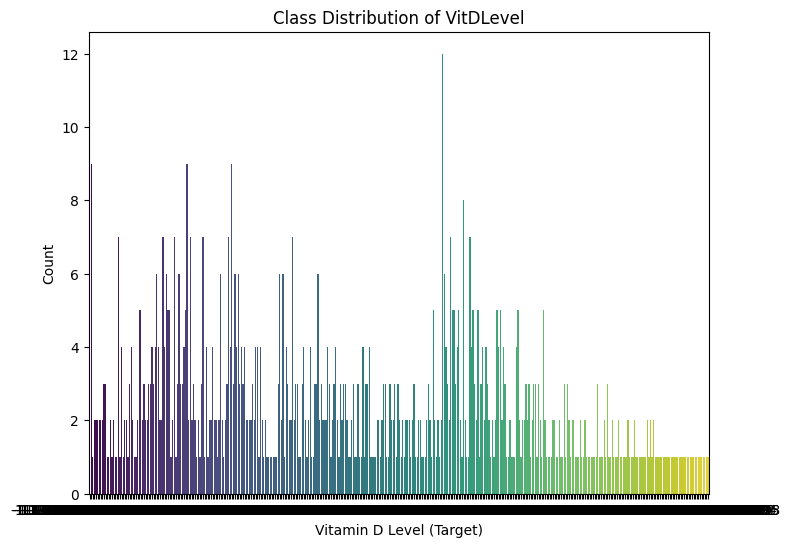

In [5]:
# Code: Plot Class Distribution
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of VitDLevel (Target Variable)
plt.figure(figsize=(8, 6))
sns.countplot(x='VitDLevel', data=df, palette='viridis')
plt.title("Class Distribution of VitDLevel")
plt.xlabel("Vitamin D Level (Target)")
plt.ylabel("Count")
plt.show()


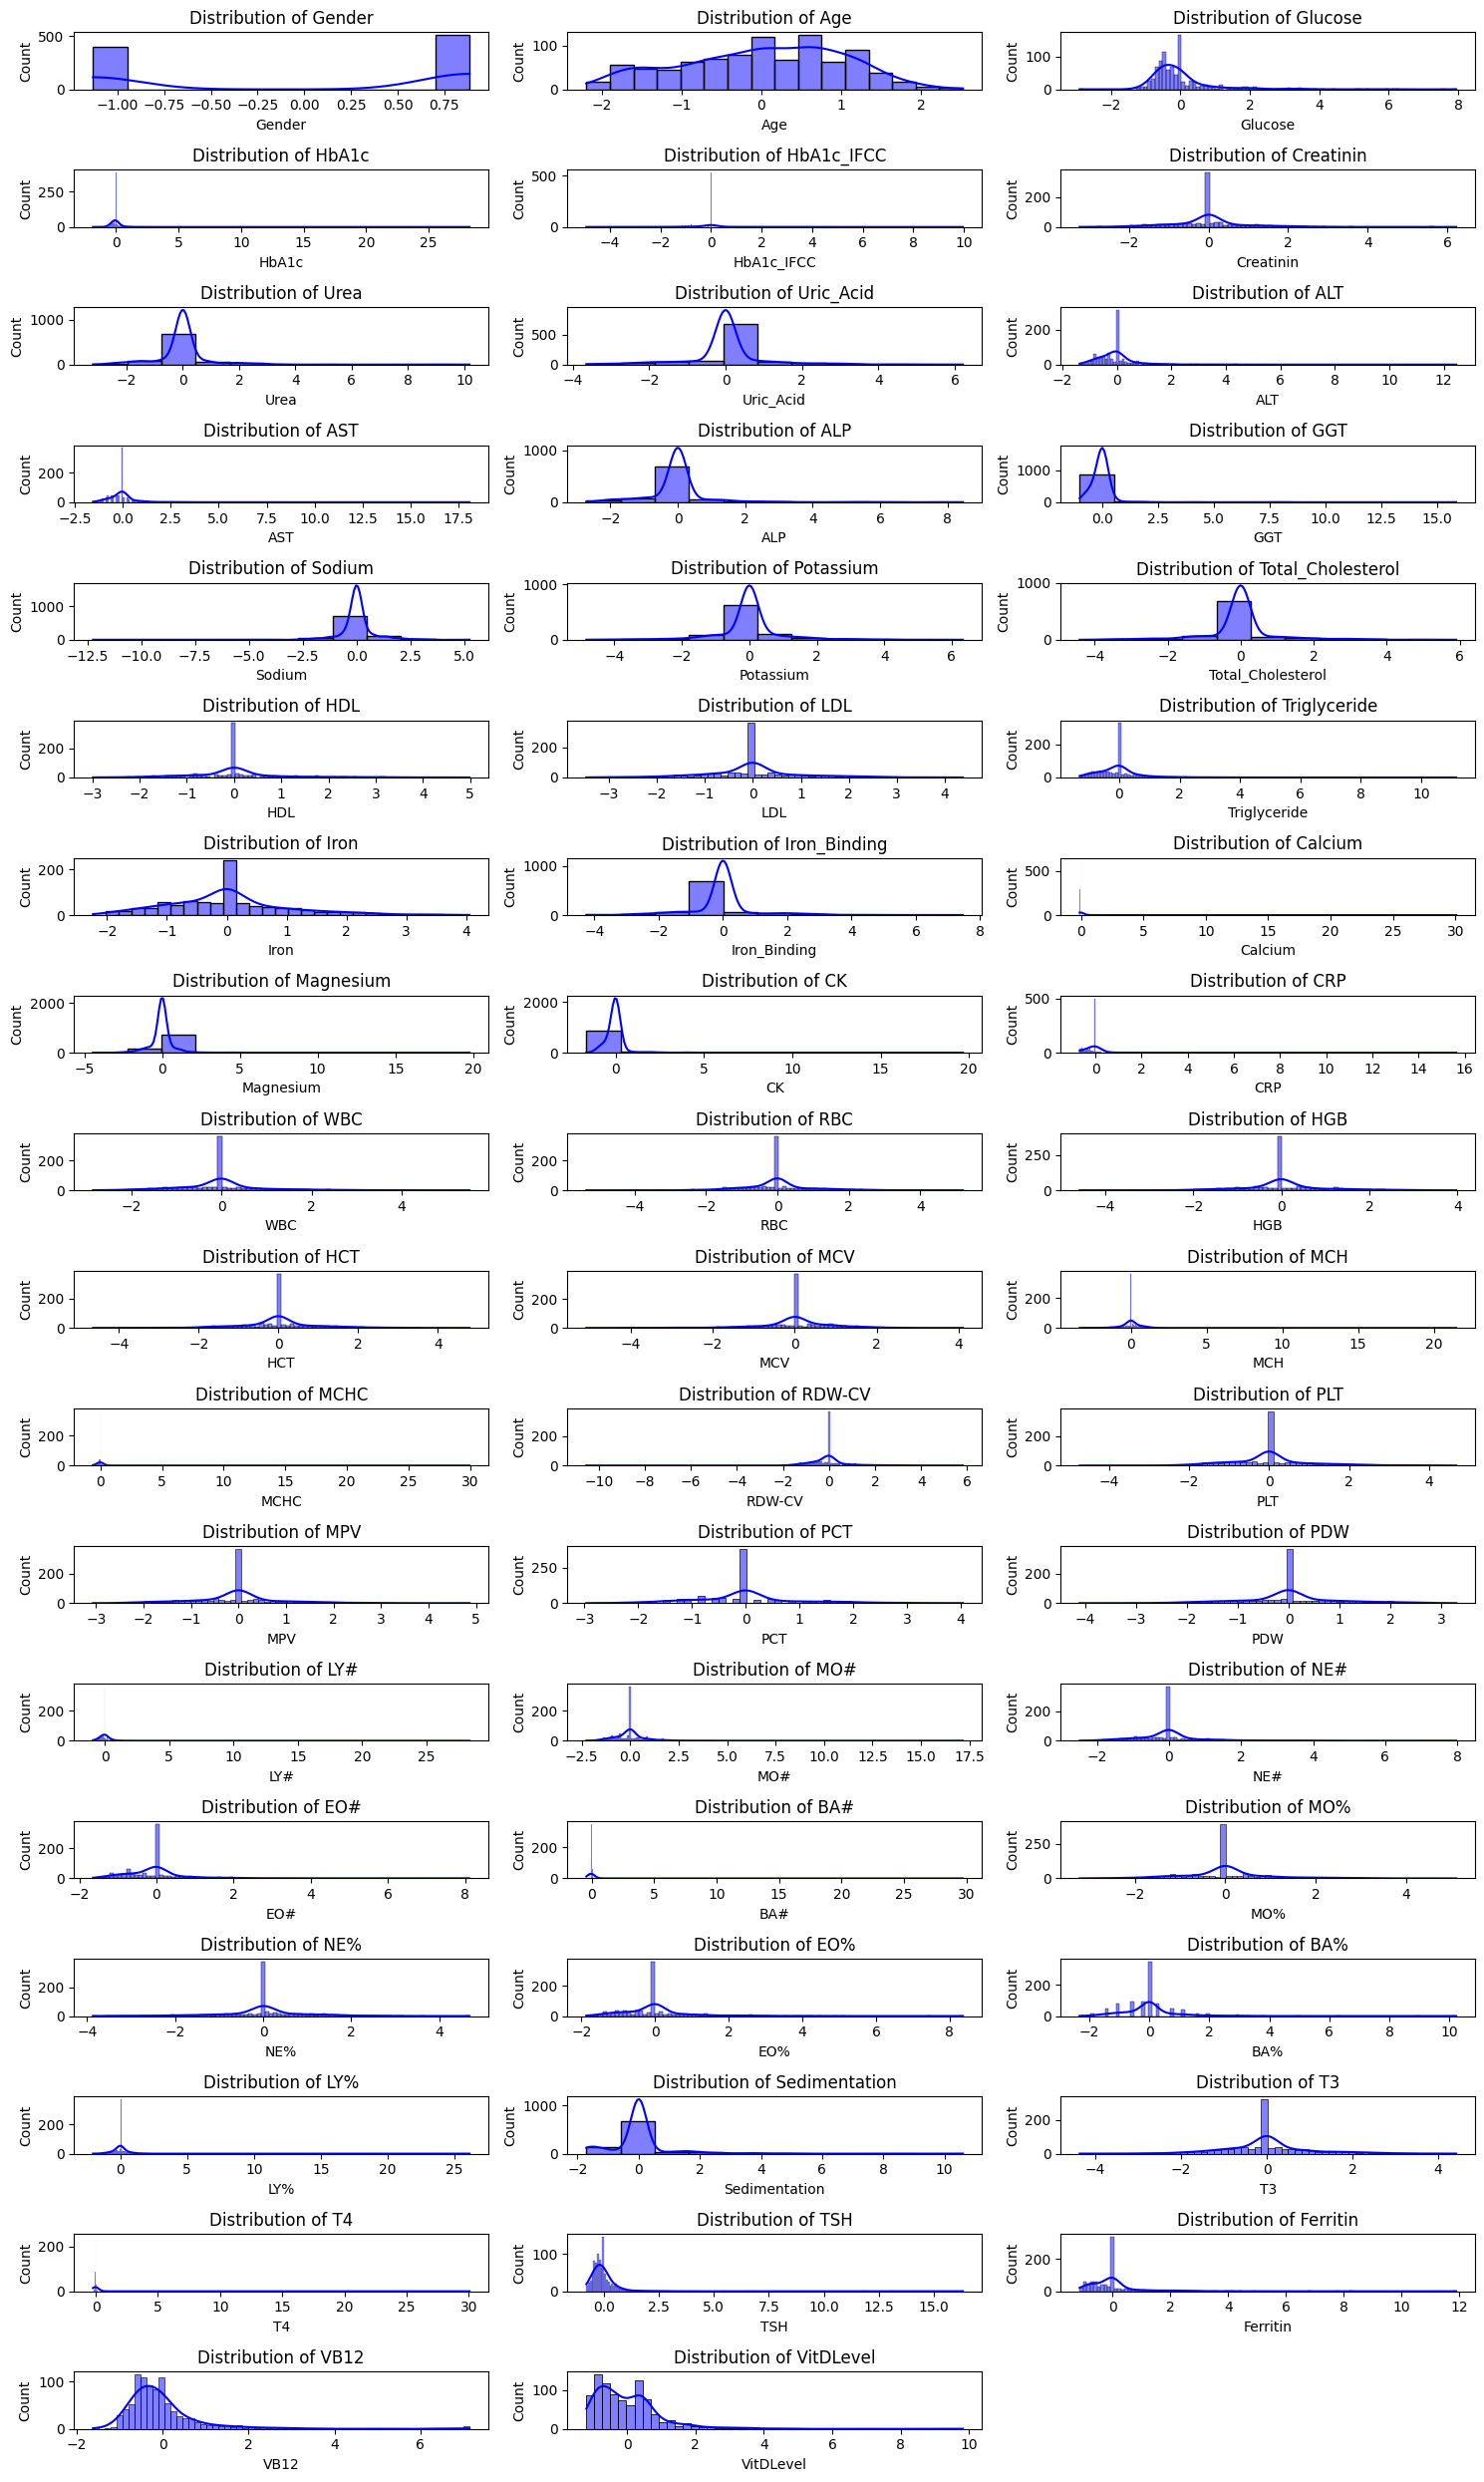

In [ ]:
# Code: Feature Distributions
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 25))
for i, column in enumerate(numerical_columns):
    plt.subplot(len(numerical_columns) // 3 + 1, 3, i + 1)
    sns.histplot(df[column], kde=True, color='blue')
    plt.title(f"Distribution of {column}")
    plt.tight_layout()
plt.show()


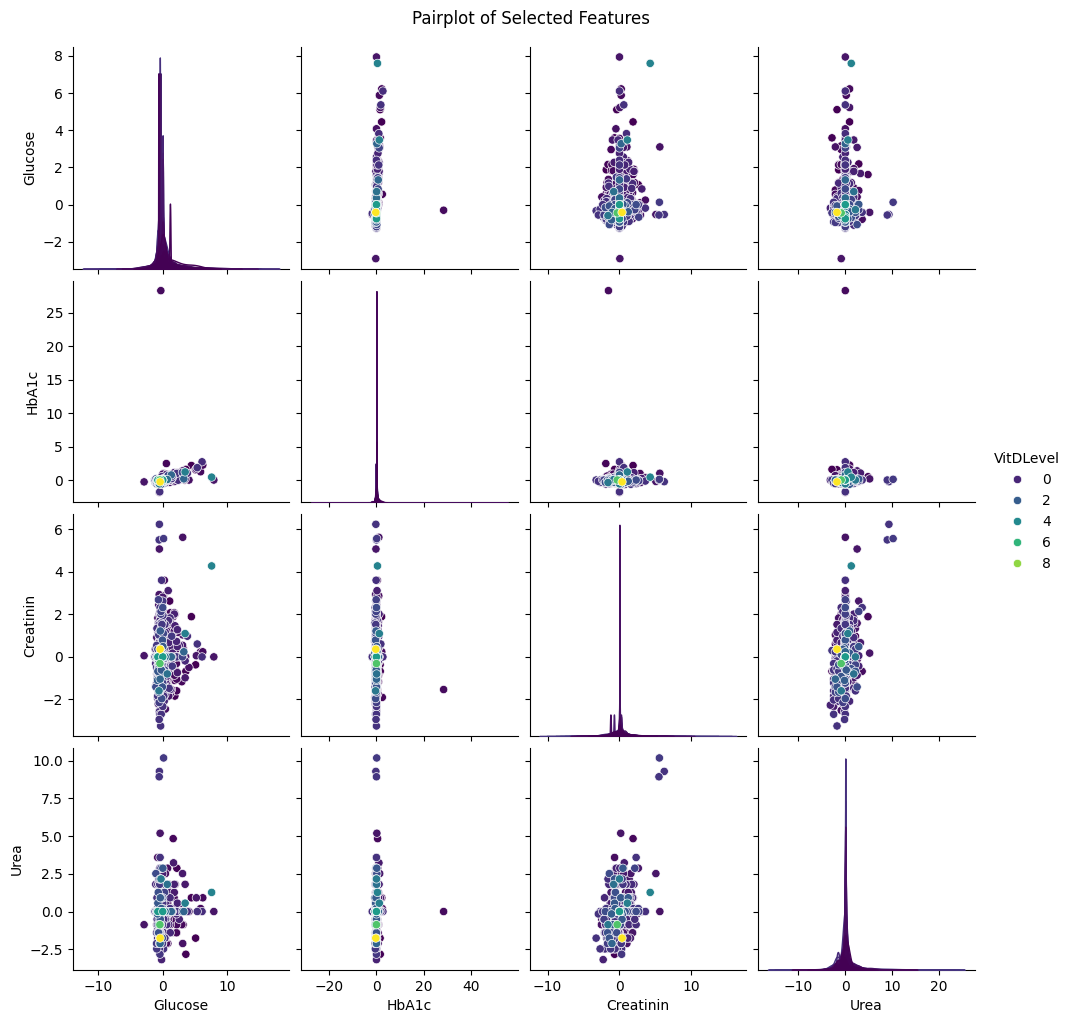

In [ ]:
# Code: Pairplot for Selected Features
selected_columns = ['Glucose', 'HbA1c', 'Creatinin', 'Urea', 'VitDLevel']  # Customize as needed
sns.pairplot(df[selected_columns], hue='VitDLevel', palette='viridis', diag_kind='kde')
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()


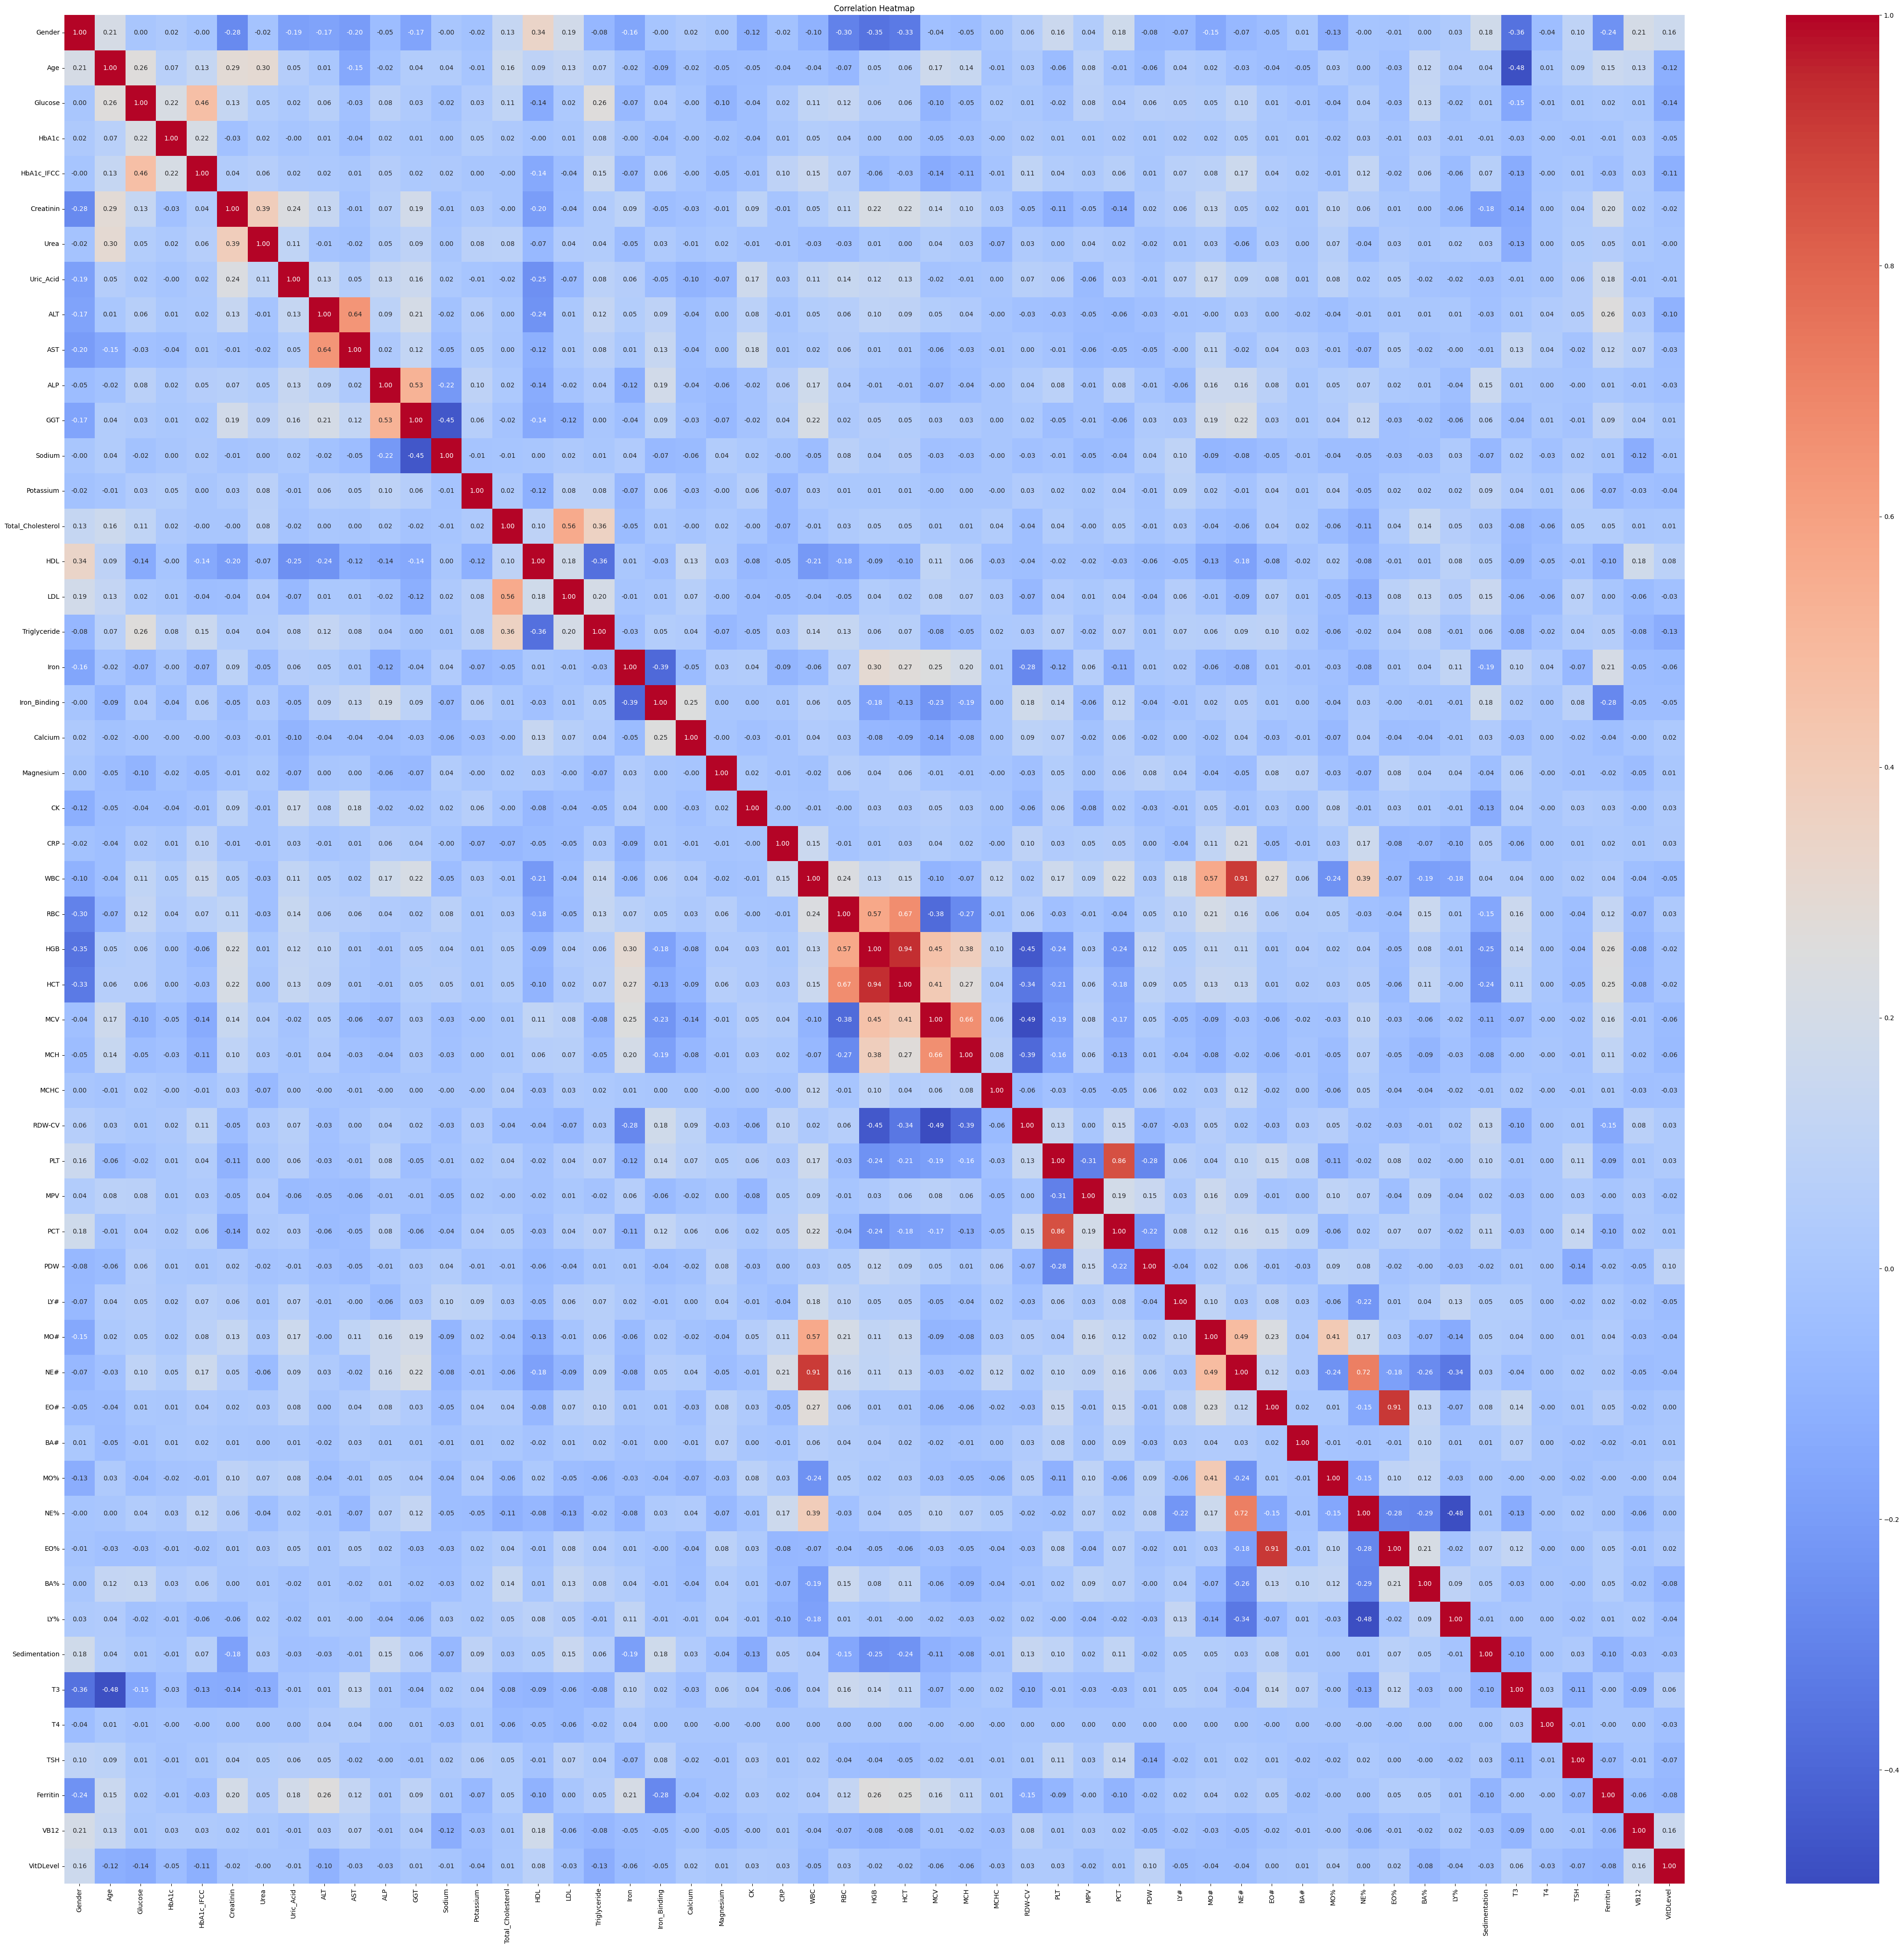

In [ ]:
# Code: Correlation Heatmap
plt.figure(figsize=(56, 52))
correlation_matrix = df.corr()

# Plot heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap")
plt.show()


In [4]:
# Check class distribution
print("Class Distribution:\n", y.value_counts())


NameError: name 'y' is not defined

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 53 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             907 non-null    float64
 1   Age                907 non-null    float64
 2   Glucose            907 non-null    float64
 3   HbA1c              907 non-null    float64
 4   HbA1c_IFCC         907 non-null    float64
 5   Creatinin          907 non-null    float64
 6   Urea               907 non-null    float64
 7   Uric_Acid          907 non-null    float64
 8   ALT                907 non-null    float64
 9   AST                907 non-null    float64
 10  ALP                907 non-null    float64
 11  GGT                907 non-null    float64
 12  Sodium             907 non-null    float64
 13  Potassium          907 non-null    float64
 14  Total_Cholesterol  907 non-null    float64
 15  HDL                907 non-null    float64
 16  LDL  

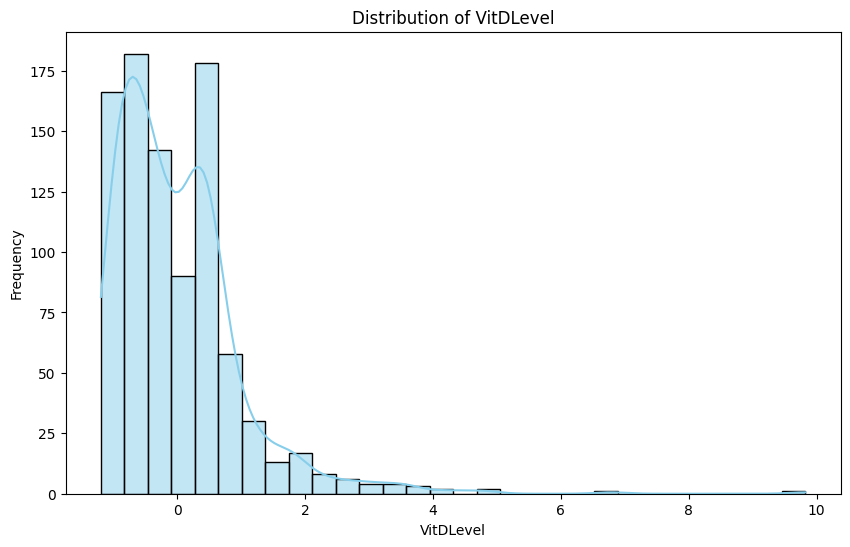


Missing Values in Each Column:
Gender               0
Age                  0
Glucose              0
HbA1c                0
HbA1c_IFCC           0
Creatinin            0
Urea                 0
Uric_Acid            0
ALT                  0
AST                  0
ALP                  0
GGT                  0
Sodium               0
Potassium            0
Total_Cholesterol    0
HDL                  0
LDL                  0
Triglyceride         0
Iron                 0
Iron_Binding         0
Calcium              0
Magnesium            0
CK                   0
CRP                  0
WBC                  0
RBC                  0
HGB                  0
HCT                  0
MCV                  0
MCH                  0
MCHC                 0
RDW-CV               0
PLT                  0
MPV                  0
PCT                  0
PDW                  0
LY#                  0
MO#                  0
NE#                  0
EO#                  0
BA#                  0
MO%                  0
NE

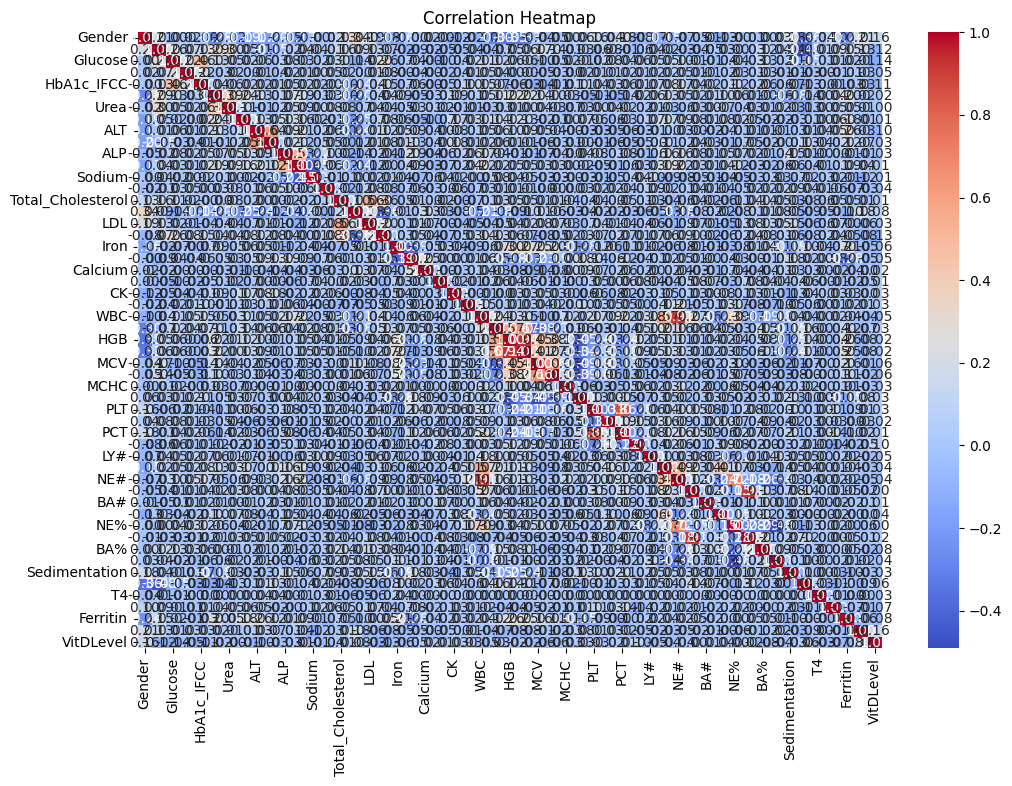

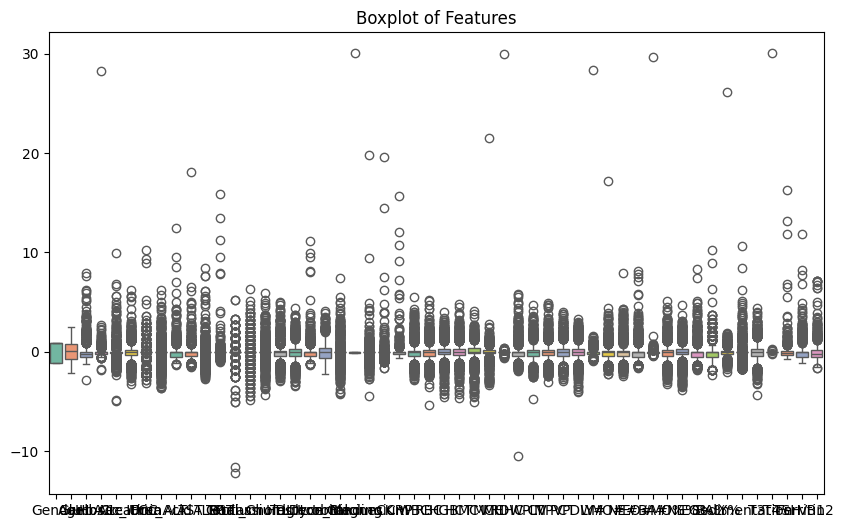

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your original dataframe
# Basic information about the data
print("Dataset Information:")
df.info()

print("\nSummary Statistics for Numeric Features:")
print(df.describe())

# Target Variable Analysis
print("\nTarget Variable Distribution (VitDLevel):")
print(df['VitDLevel'].describe())

# Plot the distribution of the target variable (VitDLevel)
plt.figure(figsize=(10, 6))
sns.histplot(df['VitDLevel'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of VitDLevel')
plt.xlabel('VitDLevel')
plt.ylabel('Frequency')
plt.show()

# Check for any missing values in the data
missing_values = df.isnull().sum()
print("\nMissing Values in Each Column:")
print(missing_values)

# Correlation heatmap of features (if there are multiple features)
if len(df.columns) > 1:  # If there are other features apart from VitDLevel
    plt.figure(figsize=(12, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.show()

# Check for outliers in the features (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop(columns=['VitDLevel']), palette='Set2')
plt.title('Boxplot of Features')
plt.show()


# **#XGBOOST**

In [6]:
# Step 1: Install and Import Necessary Libraries
!pip install xgboost

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

# Step 2: Load and Prepare Data
# Assuming 'df' is your DataFrame and 'VitDLevel' is the target variable
X = df.drop('VitDLevel', axis=1)  # Features
y = df['VitDLevel']  # Target variable

# Scaling the features (important for models like XGBoost)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 3: Train the XGBoost Model
model = xgb.XGBRegressor(
    objective='reg:squarederror',  # For regression
    colsample_bytree=0.3,
    learning_rate=0.1,
    max_depth=5,
    alpha=10,
    n_estimators=1000
)

model.fit(X_train, y_train)

# Step 4: Make Predictions
y_pred = model.predict(X_test)

# Step 5: Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")

# Displaying actual vs predicted values for a sample
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {actual}, Predicted: {predicted}")


Mean Absolute Error (MAE): 0.6418842763100884
Mean Squared Error (MSE): 0.9376990927507425
Root Mean Squared Error (RMSE): 0.9683486421484477
R-squared (R²): 0.21651245088807747
Actual: 1.8756490049102275, Predicted: 0.4046498239040375
Actual: -0.2370845865099953, Predicted: -0.1830386221408844
Actual: -0.4913390588299075, Predicted: -0.06306414306163788
Actual: 0.5862156095735297, Predicted: 0.4819270670413971
Actual: 0.7496649132077592, Predicted: 0.5169057250022888
Actual: 1.27633489158472, Predicted: -0.09461937099695206
Actual: 0.023223563722295778, Predicted: -0.35773468017578125
Actual: -0.6245199729022425, Predicted: 0.2261802852153778
Actual: 4.285012814037015, Predicted: 0.3896681070327759
Actual: 0.09586769867084208, Predicted: 0.07166269421577454


In [7]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    colsample_bytree=0.3,
    learning_rate=0.1,
    max_depth=5,
    reg_alpha=10,  # Correct parameter name
    n_estimators=1000
)

In [8]:
import xgboost as xgb
from sklearn.base import BaseEstimator, RegressorMixin

# Create a compatible XGBRegressor
class CompatibleXGBRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, **kwargs):
        self.model = xgb.XGBRegressor(**kwargs)

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)

    def __sklearn_tags__(self):
        return {"requires_fit": True, "regressor": True}

# Initialize model with corrected parameters
xgb_model_top = CompatibleXGBRegressor(
    objective='reg:squarederror',
    colsample_bytree=0.3,
    learning_rate=0.1,
    max_depth=5,
    reg_alpha=10,  # Use `reg_alpha` instead of `alpha`
    n_estimators=1000
)

In [9]:
# Step 1: Load and Preprocess Data
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

df = pd.read_excel('vitdlevel.xlsx')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Impute missing values
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

# Step 2: Feature Selection & Scaling
top_6_features = ['Age', 'Calcium', 'LDL', 'HDL', 'Iron', 'Magnesium']  # Replace with your actual top features

scaler_top = StandardScaler()
X_top = df[top_6_features]
X_top_scaled = scaler_top.fit_transform(X_top)
y = df['VitDLevel']

# Step 3: Train Model
from sklearn.model_selection import train_test_split

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top_scaled, y, test_size=0.2, random_state=42
)

xgb_model_top.fit(X_train_top, y_train_top)

# Step 4: Prediction Function
def predict_vitd(input_values):
    input_df = pd.DataFrame([input_values], columns=top_6_features)
    input_scaled = scaler_top.transform(input_df)
    pred = xgb_model_top.predict(input_scaled)[0]

    # Inverse scaling (if VitDLevel was scaled earlier)
    # pred_actual = pred * vitd_std + vitd_mean  # Uncomment if needed

    if pred >= 30:
        return "VitD Sufficiency"
    elif 21 <= pred <= 29:
        return "VitD Insufficiency"
    elif 11 <= pred <= 20:
        return "Mild VitD Deficiency"
    elif 5 <= pred <= 10:
        return "Moderate VitD Deficiency"
    else:
        return "Severe VitD Deficiency"

In [18]:
print(df[['Age', 'Calcium', 'LDL', 'HDL', 'Iron', 'Magnesium']])



      Age   Calcium         LDL        HDL        Iron  Magnesium
0    63.0   9.10000  142.000000  47.000000   91.000000   2.074941
1    72.0   8.82000   83.000000  64.000000   91.000000   2.074941
2    65.0  41.37932  123.180702  47.723684   78.039136   2.074941
3    56.0   9.32000  168.000000  47.000000   75.000000   2.110000
4    49.0   9.89000  131.000000  60.000000   67.000000   2.074941
..    ...       ...         ...        ...         ...        ...
902  45.0  41.37932  123.180702  47.723684   59.000000   2.074941
903  24.0  41.37932  123.180702  47.723684  102.000000   2.074941
904  55.0  41.37932  123.180702  47.723684   78.039136   2.074941
905  33.0  41.37932  123.180702  47.723684   82.000000   2.074941
906  43.0  41.37932  126.000000  48.000000  126.000000   2.074941

[907 rows x 6 columns]


In [19]:
sample_input = {
    'Age': 63,
    'Calcium': 9.10,
    'LDL': 142,
    'HDL': 47,
    'Iron': 91,
    'Magnesium': 2.074941
}

print(predict_vitd(sample_input))

Moderate VitD Deficiency


# **#RandomForest**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Load your data (replace with your dataset)
# data = pd.read_csv('your_data.csv')
# X = data.drop(columns=['target_column'])  # Replace with your features
# y = data['target_column']  # Replace with your target

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and train the model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")

# Print Actual vs Predicted values for a sample
for actual, pred in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {actual}, Predicted: {pred}")


Mean Absolute Error (MAE): 0.6841015045537553
Mean Squared Error (MSE): 1.0570306798375608
Root Mean Squared Error (RMSE): 1.0281199734649458
R-squared (R²): 0.11680582493409475
Actual: 1.8756490049102275, Predicted: -0.13294322471544495
Actual: -0.2370845865099953, Predicted: -0.06793526358051104
Actual: -0.4913390588299075, Predicted: 0.23639767157956734
Actual: 0.5862156095735297, Predicted: 0.16114207866592545
Actual: 0.7496649132077592, Predicted: 0.32801916104050194
Actual: 1.27633489158472, Predicted: 0.266895840314386
Actual: 0.023223563722295778, Predicted: -0.17911775008569691
Actual: -0.6245199729022425, Predicted: -0.11490085460391673
Actual: 4.285012814037015, Predicted: 0.16501299663364388
Actual: 0.09586769867084208, Predicted: -0.13993548865099656


# **#LightGBM**

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set the parameters for the LightGBM model
params = {
    'objective': 'regression',  # Regression task
    'metric': 'mean_squared_error',  # Metric for regression
    'boosting_type': 'gbdt',  # Gradient Boosting Decision Tree
    'num_leaves': 31,  # Number of leaves in full trees
    'learning_rate': 0.05,  # Learning rate
    'feature_fraction': 0.9  # Fraction of features to use at each iteration
}

# Create the LightGBM dataset for training
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Train the model with early stopping using the fit() function
lgb_model = lgb.train(params, train_data, valid_sets=[test_data])

# Make predictions
y_pred = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5  # Equivalent to np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")

# Print Actual vs Predicted values for a sample
for actual, pred in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {actual}, Predicted: {pred}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.128314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4012
[LightGBM] [Info] Number of data points in the train set: 725, number of used features: 52
[LightGBM] [Info] Start training from score -0.001470
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

# **#GradientBoostingRegressor**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the GradientBoostingRegressor model
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model on the training data
gb_model.fit(X_train, y_train)

# Make predictions
y_pred = gb_model.predict(X_test)

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5  # Equivalent to np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")

# Print actual vs predicted values for a sample
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {actual}, Predicted: {predicted}")


Mean Absolute Error (MAE): 0.6906591145716173
Mean Squared Error (MSE): 1.029272243724725
Root Mean Squared Error (RMSE): 1.0145305533717184
R-squared (R²): 0.13999918114544252
Actual: 1.8756490049102275, Predicted: 0.21641336312673465
Actual: -0.2370845865099953, Predicted: 0.6404344074556042
Actual: -0.4913390588299075, Predicted: -0.001097824373515742
Actual: 0.5862156095735297, Predicted: 0.1371233639270881
Actual: 0.7496649132077592, Predicted: 0.5997344758514482
Actual: 1.27633489158472, Predicted: 0.5829683491106595
Actual: 0.023223563722295778, Predicted: -0.29304088810128476
Actual: -0.6245199729022425, Predicted: 0.12293618847200385
Actual: 4.285012814037015, Predicted: 0.3086567710031361
Actual: 0.09586769867084208, Predicted: 0.13197607936139447


# **#ElasticNET**

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the ElasticNet model
elasticnet_model = ElasticNet(alpha=1.0, l1_ratio=0.5)

# Train the model
elasticnet_model.fit(X_train, y_train)

# Make predictions
y_pred = elasticnet_model.predict(X_test)

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5  # Equivalent to np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")

# Print actual vs predicted values for a sample
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {actual}, Predicted: {predicted}")


Mean Absolute Error (MAE): 0.7644891533051515
Mean Squared Error (MSE): 1.196880749269484
Root Mean Squared Error (RMSE): 1.0940204519429626
R-squared (R²): -4.48673502750907e-05
Actual: 1.8756490049102275, Predicted: -0.0014704322198687838
Actual: -0.2370845865099953, Predicted: -0.0014704322198687838
Actual: -0.4913390588299075, Predicted: -0.0014704322198687838
Actual: 0.5862156095735297, Predicted: -0.0014704322198687838
Actual: 0.7496649132077592, Predicted: -0.0014704322198687838
Actual: 1.27633489158472, Predicted: -0.0014704322198687838
Actual: 0.023223563722295778, Predicted: -0.0014704322198687838
Actual: -0.6245199729022425, Predicted: -0.0014704322198687838
Actual: 4.285012814037015, Predicted: -0.0014704322198687838
Actual: 0.09586769867084208, Predicted: -0.0014704322198687838


# **#AdaBoost**

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create AdaBoost model with the default base estimator (a decision tree)
ada_model = AdaBoostRegressor(n_estimators=100, learning_rate=0.00001)

# Fit the model
ada_model.fit(X_train, y_train)

# Make predictions
y_pred = ada_model.predict(X_test)

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5  # Equivalent to np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")

# Print actual vs predicted values for a sample
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {actual}, Predicted: {predicted}")


Mean Absolute Error (MAE): 0.6940798630101452
Mean Squared Error (MSE): 1.1018418367619824
Root Mean Squared Error (RMSE): 1.0496865421457886
R-squared (R²): 0.07936419383622029
Actual: 1.8756490049102275, Predicted: -0.08211348166489123
Actual: -0.2370845865099953, Predicted: -0.08503469068690435
Actual: -0.4913390588299075, Predicted: 0.001315015087019806
Actual: 0.5862156095735297, Predicted: 0.007932421736212761
Actual: 0.7496649132077592, Predicted: 0.07407051442216588
Actual: 1.27633489158472, Predicted: 0.18256771702219293
Actual: 0.023223563722295778, Predicted: -0.07693168764230315
Actual: -0.6245199729022425, Predicted: -0.08799344766900931
Actual: 4.285012814037015, Predicted: 0.037920548431793176
Actual: 0.09586769867084208, Predicted: -0.0668302619600779


# **#Compare MAE**

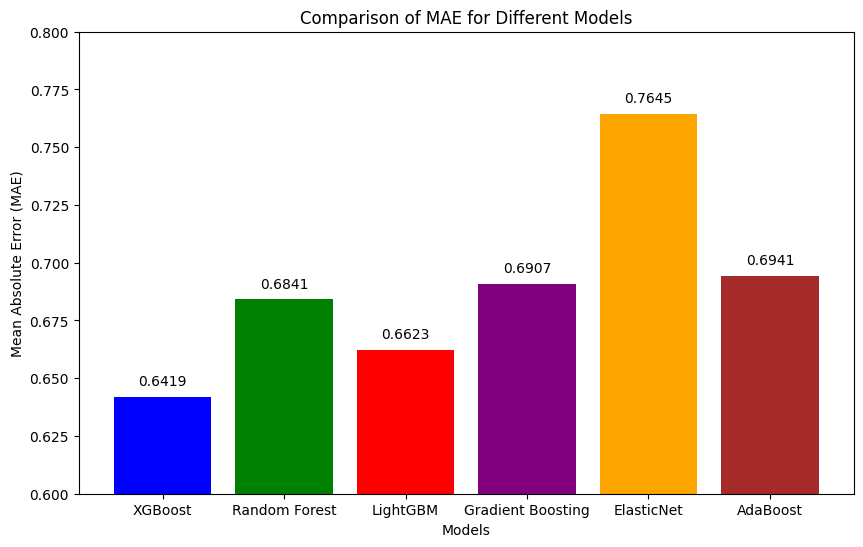

In [ ]:
import matplotlib.pyplot as plt

# Model names and corresponding MAE values
models = ["XGBoost", "Random Forest", "LightGBM", "Gradient Boosting", "ElasticNet", "AdaBoost"]
mae_values = [0.6419, 0.6841, 0.6623, 0.6907, 0.7645, 0.6941]

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, mae_values, color=['blue', 'green', 'red', 'purple', 'orange', 'brown'])

# Add labels and title
plt.xlabel("Models")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("Comparison of MAE for Different Models")
plt.ylim(0.6, 0.8)  # Adjusting y-axis range for better visualization

# Display values on bars
for i, v in enumerate(mae_values):
    plt.text(i, v + 0.005, str(v), ha='center', fontsize=10)

# Show the plot
plt.show()
